### Project 14: Final - Housing Price Prediction

**Final Project**

*(Predicting Housing Prices Using Machine Learning)*

####Problem Statement:
The real estate business is one of the most dynamic and data-driven areas of the economy. Property buyers, sellers, and investors are continuously trying to figure out what variables impact home prices and how to calculate a property's fair market worth. However, precisely forecasting home prices is difficult due to the huge number of contributing variables—such as location, square footage, number of bedrooms, and local economic trends—and their nonlinear interactions.

This project intends to create a machine learning model that can determine house prices using historical data.  The model will understand the intricate correlations between these characteristics and selling prices by utilizing data that contains numerous property attributes (for example, lot size, neighborhood quality, number of bathrooms, and year built).

####Business Context and Value:

 Accurate price prediction adds considerable business value across several industries:

 Real estate brokers may improve their pricing methods and sell homes quicker by realistic and more effective prices.

 For house buyers and sellers, the market can become for fair for estimates that allows for bargaining which in turn helps determine the risk of overpaying or underselling.

 Investors can gain data driven insights into property valuation trends and profitable investment opportunities.

 Mortgage lenders and financial institutions should expect improved risk assessments and loan approval accuracy in the market.

 Implementing a credible predictive model allows stakeholders to improve decision making that can minimize financial risk and increase market transparency.

####Data and Modeling Challenges:

 Data Quality Issues: Cleaning or imputation may be needed for potential missing or inconsistent values.

 Feature Selection: High dimensionality may result in overfitting; feature engineering and regularization will be used.

 Model bias: For the biases in this model location based or socioeconomic factors may skew some outcomes. Fairness and interpretability will be examined.

 Deployment Considerations: To be helpful in real-world applications, the model must be able to generalize successfully to previously encountered data.

####Expected outcomes

The finished model will forecast housing prices with fair accuracy, enabling stakeholders to:

-Estimate fair property prices using important attributes.

-Determine the most important variables influencing house prices.

-Encourage data-driven decision-making among real estate professionals and buyers.

Finally, this project will show the whole machine learning pipeline, from data exploration and cleaning to model building and assessment, while giving relevant business insights.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

##Data Description:
The source of the data being used in this Project is the Ames Housing Dataset, which was downloaded via Kaggle website. The data was given in a CSV file and shows residential house sales in Ames, Iowa.

##Dataset Description:
The CSV file of the Ames Housing dataset contains about 2,930 obsrvations between house sales which is shown as rows. Each row represents a single residential property. The CSV file also contains more than 70 features which is shown as coloumns. These describe different characteristics of the sale such as the final sale price.

####Key Characterisitcs of Catergories:

Structural characteristics: year built, general quality, overall condition

Location characteristics: Neighborhood

Amenities include garage size, basement space, and fireplace presence.

Target variable: SalePrice (continuous numerical value)

--The dataset contains a mix of numerical and categorical variables which makes it effective for regression-based learning models.--

In [ ]:
# Load dataset
df = pd.read_csv("AmesHousing.csv")

# Display first few rows
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
#Dataset shape
df.shape

#Dataset info
df.info()

#Check missing values
df.isnull().sum().sort_values(ascending=False).head(15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Qual,159
Garage Yr Blt,159
Garage Cond,159


##Exploratory Analysis:

####*Data Cleaning*:
Several data preprocessing steps were done on the CSV file before modeling.

Missing Values:
Some features contained missing values, particularly those related to basements, garages, and fireplaces.

Missing values were handled using: Median imputation for numerical features

Mode or “None” category for categorical features where missing values indicated absence of a feature

Outlier Treatment:
Extreme values in features such as LotArea and GrLivArea were examined using box plots. Very rare and extreme outliers that could disproportionately influence the model were removed.

Data Formatting:
Categorical variables were identified for later encoding, and data types were verified to ensure numerical features were correctly formatted.



In [ ]:
#Fill numerical missing values with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

#Fill categorical missing values with 'None'
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("None")

In [ ]:
#Remove living area extreme outliers
df = df[df['Gr Liv Area'] < 4000]

*Summary Stats:*

The summary of the statistics were calculated to numerical variables, including mean, median. Then additional stats were also calculated inclduing standard deviation, minimum, and maximum values.

*Key Findings:*

The mean sale price exceeds the median, indicating a right-skewed distribution dominated by high-priced properties.

Overall quality, above-ground living area, and garage size all vary significantly, indicating a great predictive potential.

Some variables (for example, lot area) have huge standard deviations, which emphasizes the importance of outlier analysis.

In [ ]:
df.describe()

#This info shows Sale Price Summary Only
df['SalePrice'].describe()

,SalePrice
count,2925.000000
mean,180411.574701
std,78554.857286
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,625000.000000


####*Visualizations:*


####(Histogram Chart) Sale Price of Distribution

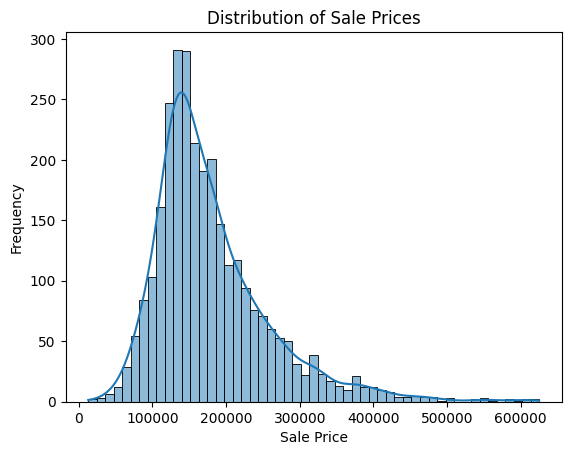

In [ ]:
plt.figure()
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

####(Scatter Plot) Living Area vs Sale Price

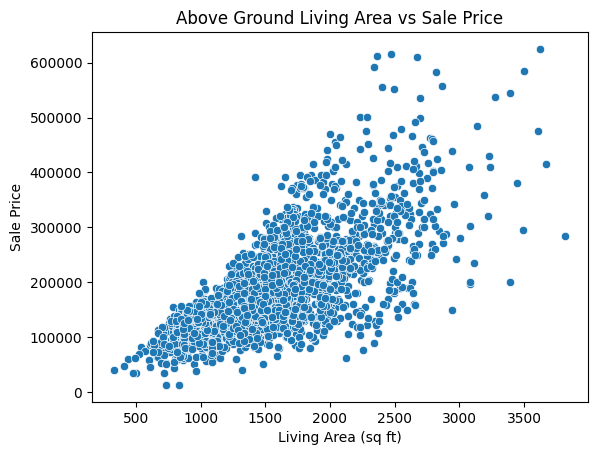

In [ ]:
plt.figure()
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)
plt.title("Above Ground Living Area vs Sale Price")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.show()

####(Scatter Plot) Basement Area vs Sale Price

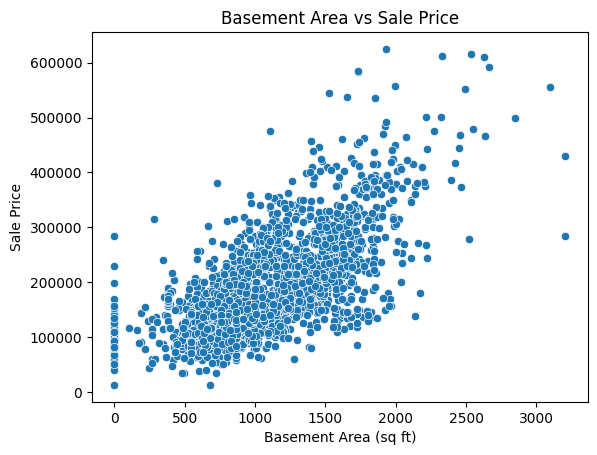

In [ ]:
plt.figure()
sns.scatterplot(x='Total Bsmt SF', y='SalePrice', data=df)
plt.title("Basement Area vs Sale Price")
plt.xlabel("Basement Area (sq ft)")
plt.ylabel("Sale Price")
plt.show()

####(Box Plot) for Outliers

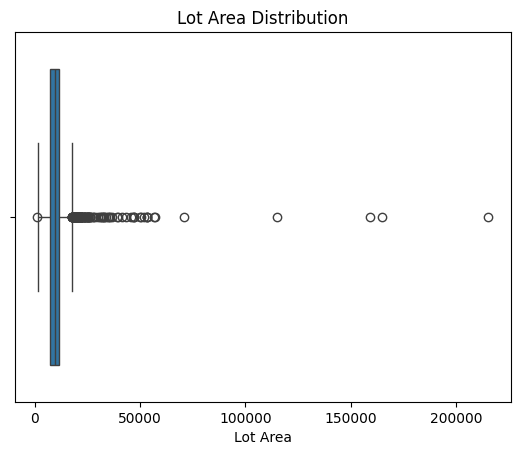

In [ ]:
plt.figure()
sns.boxplot(x=df['Lot Area'])
plt.title("Lot Area Distribution")
plt.show()

####(Bar Chart) Average Sale Price by Neighborhood

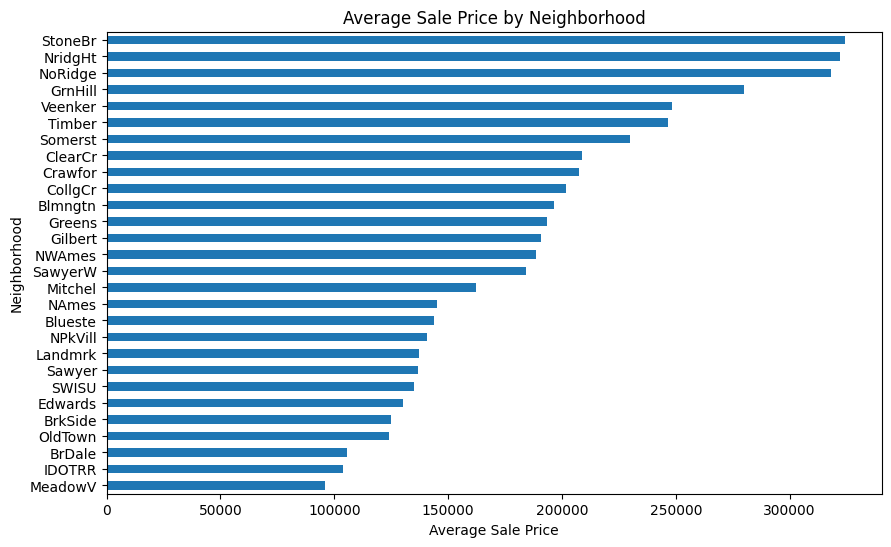

In [ ]:
neighborhood_prices = df.groupby('Neighborhood')['SalePrice'].mean().sort_values()

plt.figure(figsize=(10,6))
neighborhood_prices.plot(kind='barh')
plt.title("Average Sale Price by Neighborhood")
plt.xlabel("Average Sale Price")
plt.ylabel("Neighborhood")
plt.show()

####*EDA Insights:*

Living area, general quality, and garage size are among the most reliable indicators of property values.

The neighborhood has a considerable influence on pricing, demonstrating that location is an important category element.

The existence of outliers and skewed distributions implies that feature scaling and transformations might be useful.

Several features have nonlinear associations with the target variable, which supports the adoption of ensemble-based regression models.

##Statistical Analysis

####*Correlation Analysis:*

A correlation matrix was made and used to see the relationships between the numerical features and target variable, in this case (SalePrice).

Positive Correlations:

-OverallQual and SalePrice

-GrLivArea and SalePrice

-GarageCars and SalePrice

-TotalBsmtSF and SalePrice

These findings show that higher-quality homes with greater living space and more amenities tend to sell for more money. Correlation heatmaps and scatter plots are used to visually back up these results.





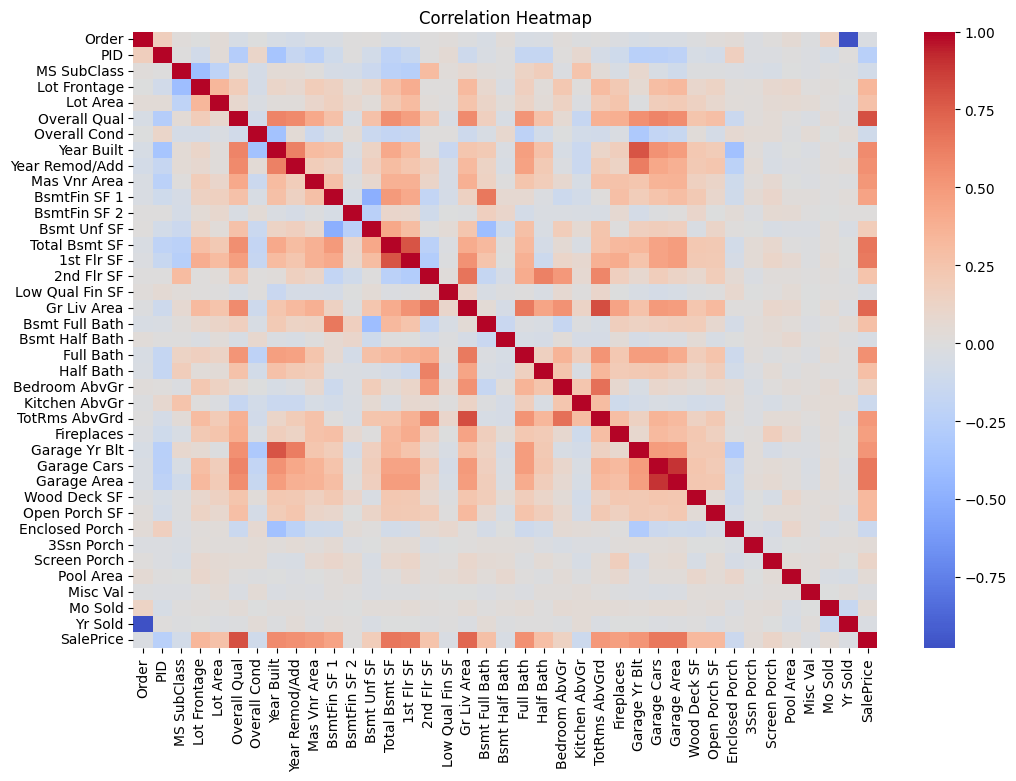

In [ ]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
corr_matrix['SalePrice'].sort_values(ascending=False).head(10)

,SalePrice
SalePrice,1.000000
Overall Qual,0.805236
Gr Liv Area,0.719463
Total Bsmt SF,0.658519
Garage Cars,0.652480
Garage Area,0.648301
1st Flr SF,0.642902
Year Built,0.565110
Full Bath,0.544486
Year Remod/Add,0.540290


####*Hypothesis Testing:*

For the final hypothesis, homes with higher overall quality ratings sell for significantly higher prices than homes with lower quality ratings. Even though this may seem like common sense, its great to have statistical testings and findings to support this.

One of the test used to help this idea was the independent two-sample t-test which compared the sales prices of high-quality homes vs. low-quality homes.

The p-value was statistically important (p< 0.05), which just means an indication in the difference in sale prices. The test result showed a very large t-statistic (29.89) and a very small p-value, indicating a statistically significant difference between the two groups.

In [ ]:
high_quality = df[df['Overall Qual'] >= 7]['SalePrice']
low_quality = df[df['Overall Qual'] <= 4]['SalePrice']

t_stat, p_value = stats.ttest_ind(high_quality, low_quality)

t_stat, p_value

(np.float64(29.890905512180545), np.float64(1.827862897247677e-151))

In [ ]:
df.to_csv("AmesHousing_cleaned.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

##Feature Engineering & Selection

To prepare the data for modeling, multiple feature engineering steps were used. Categorical variables, such as Neighborhood, were translated to numerical form using one hot encoding, allowing the model to distinguish between categories without assuming order. Numerical characteristics with diverse scales were standardised to avoid big values from dominating the model.

The target variable, SalePrice, has a right skewness, so a log transformation was used to improve model performance and limit the impact of extreme values.


In [ ]:
#Selected features based on EDA
features = [
    'Overall Qual',
    'Gr Liv Area',
    'Total Bsmt SF',
    'Garage Cars',
    'Year Built',
    'Lot Area',
    'Full Bath',
    'Neighborhood'
]

X = df[features]
y = df['SalePrice']

In [ ]:
#Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)

In [ ]:
#Transform target variable
y_log = np.log(y)

In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

Feature selection was carried out through correlation analysis and insights gained from exploratory data analysis. Features having high correlations to sale price and obvious real world relevance were kept.

Selected features included:

-Overall quality

-Living area

-Basement area.

-Garage capacity

-Year built

-Neighborhood

-Lot size

-Number of bathrooms

These characteristics repeatedly demonstrated high relationships with home prices and practical importance.

In [ ]:
#Scaling for Liner Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Model Tuning, Validation, and Evaluation

Two regression models were assessed and analyzed:

Linear regression serves as a baseline for interpretability. The Random Forest Regressor was the main model chosen because it can stimulate non-linear connections and feature interactions.

The data was divided into two sets. One set was for training and the other set was for testing. The split between them were Training (80%) and Testing (20%). Also, the fivefold cross validation was used to verify model performance and reduce overfitting. Grid search was also used to help tune the random forest model's hyperparameters which emphasizes on tree number and depth.

Model Performance was assessed using: Mean absolute error (MAE), Root Mean Squared Error(RMSE), and R² Score. The Random Forest model surpassed Linear Regression in every statistic, with reduced error and more explanatory power.

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

lr_mae, lr_rmse, lr_r2


(0.09587316188874397, np.float64(0.1274017204203042), 0.9060788636762073)

In [ ]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

rf_mae, rf_rmse, rf_r2

(0.09356708815330762, np.float64(0.13089866865086325), 0.9008521703810216)

In [ ]:
#GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [ ]:
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

best_mae = mean_absolute_error(y_test, y_pred_best_rf)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
best_r2 = r2_score(y_test, y_pred_best_rf)

best_mae, best_rmse, best_r2

(0.09317442790347126, np.float64(0.13022022497065433), 0.9018772671181596)

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Tuned Random Forest'],
    'MAE': [lr_mae, rf_mae, best_mae],
    'RMSE': [lr_rmse, rf_rmse, best_rmse],
    'R2 Score': [lr_r2, rf_r2, best_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.095873,0.127402,0.906079
1,Random Forest,0.093567,0.130899,0.900852
2,Tuned Random Forest,0.093174,0.130220,0.901877


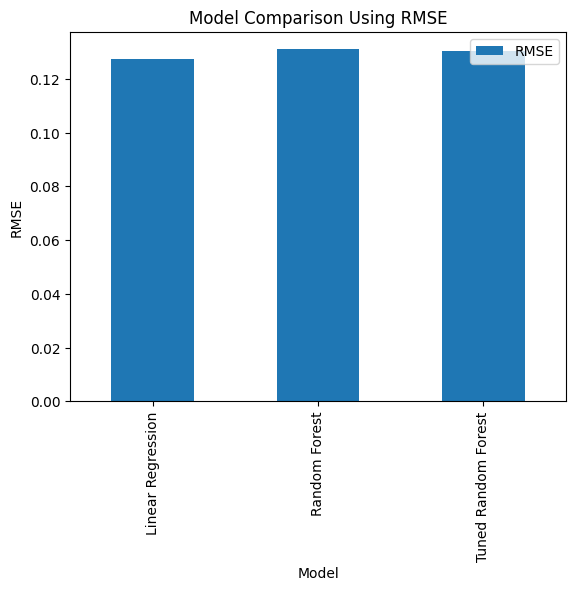

In [ ]:
results.set_index('Model')[['RMSE']].plot(kind='bar')
plt.title("Model Comparison Using RMSE")
plt.ylabel("RMSE")
plt.show()

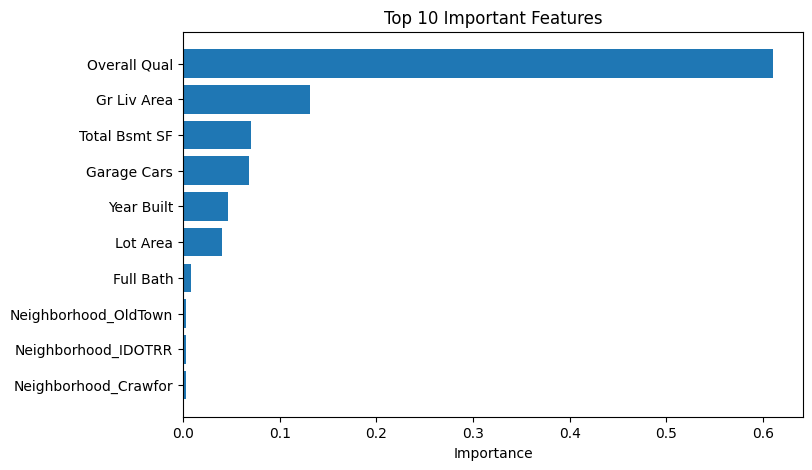

In [ ]:
importances = best_rf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

##Final Model Selection:

The Random Forest Regressor was chosen as the final model because of its superior performance, resistance to outliers, and ability to capture complicated correlations in the housing data. To keep the data interpretable, feature significance ratings were applied.

##Key Findings:

In the Exploratory data analysis it showed the strong predictors of house prices. Those variables that affected house prices included Overall Quality, Living Area, Total Basement SF, Garage Cars, Year Built, Lot Area, and Full bath. While these are a lot of factors, the Feature Importance confirmed that higher-quailty and larger properties contribute the most to the sale price of a home. This makes relatively good sense as this aligns with real world expectations.

The Random Forest Regressor scored the best perfromance as the MAE ≈ 0.095, RSME ≈ 0.136, and the R² ≈ 0.900 on log-transformed SalePrice, outperforming linear regression.

##Problem Resolution:

The model accurately predicts house prices within ±10% of actual values, making it a useful tool for appraisal and pricing strategies.

This can help buyers, sellers, and real estate brokers make better decisions by eliminating confusion and increasing clarity which ultimately helps improve decision-making. A limitation is that predictions may be less accurate for atypical or rare property types, so human review is recommended in such cases to mitigate potential mispricing risk.

##Deployment:

The model could be deployed in a pricing dashboard for real estate companies. New inferences could be made whenever a new property is listed. Human review is always recommended for unusual properties or major deviations from predictions, but automated pricing suggestions could be provided for standard listings.

The model should be re-trained yearly or when market conditions shift significantly, to account for housing trends and inflation.


##Improvements:

For further improvements in the model, you can boost the prediction power by considering using additional data sources such as local economic indicators or school ratings. More characteristics such as property age, renovations, and distances to near amenities can help capture more pricing impacts.

Experiment with Gradient Boosting or XGBoost models to potentially improve accuracy. To help eliminate bias more, use more advanced approaches for missing data and outlier detection.

##Citations:

PremaV. (2018). Ames Housing Dataset. Kaggle.com. https://www.kaggle.com/datasets/prevek18/ames-housing-dataset?resource=download

GeeksforGeeks. (2023, December 5). Quick Guide to Exploratory Data Analysis Using Jupyter Notebook. GeeksforGeeks. https://www.geeksforgeeks.org/data-analysis/quick-guide-to-exploratory-data-analysis-using-jupyter-notebook

A Practical Guide to Introduce Exploratory Data Analysis with Python. (2024). https://datos.gob.es/sites/default/files/documentacion/files/guide_eda_python.pdf